---
# Create Torus
---

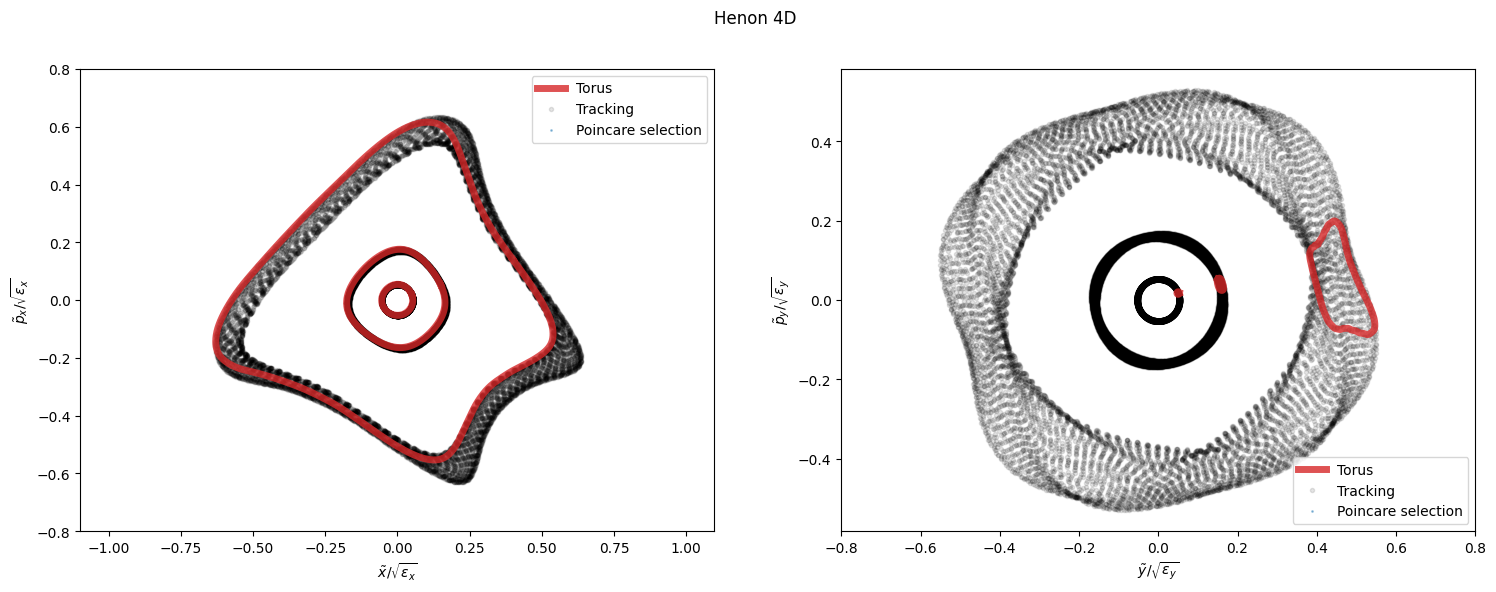

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus
import nafflib.naomi as mi



# Henon parameters:
# ---
nturns = int(5e4)
points = np.array([0.05,0.15,0.4])[::-1]
# points = np.linspace(0.05,0.6,10)
slope  = 0.35

# coupling = 0.4
# Qx0 = 0.25 - 4*np.sqrt(3)/1000
# Qy0 = np.sqrt(2) - 1

coupling = 0.3
Qx0 = 0.25 - 2*np.sqrt(3)/1000
Qy0 = np.sqrt(2) - 1
# ------------



particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx0,
                                                                            Qy = Qy0,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)



fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    N_start = 0


    n_harm = 150
    w_order= 4
    Qvec   = [nafflib.tune(part[plane],part[f'p{plane}'],window_order=w_order) for plane in ['x','y']]
    Ax,Qx  = nafflib.harmonics( part['x'],part[f'px'],num_harmonics = n_harm,window_order=w_order)
    Ay,Qy  = nafflib.harmonics( part['y'],part[f'py'],num_harmonics = n_harm,window_order=w_order)
    

    max_n       = 40
    max_alias   = 10
    warning_tol = 1e-7
    nx  = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    ny  = nafflib.linear_combinations(Qy,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)

    if p_idx == 2:
        Ix_avg  = mi.pdq_avg_integral(Ax,nx,idx=0) + mi.pdq_avg_integral(Ay,ny,idx=0)
        Iy_avg  = mi.pdq_avg_integral(Ax,nx,idx=1) + mi.pdq_avg_integral(Ay,ny,idx=1)
        Ay = [np.sqrt(2*Iy_avg)*np.exp(1j*np.angle(part['y'][0] - 1j*part['py'][0])),np.sqrt(1e-5)]
        Qy = [Qvec[1],-Qvec[0]]
        ny = [(0,1,0),(-1,0,0)]
        # break
    mytorus = pytorus.Torus(Ax,Ay,nx,ny)
    

    theta_vec   = 2 * np.pi*Qvec[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*Qvec[1]* N_start
    

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    # plt.plot(x_r,px_r,'.',ms=2,color='C0',alpha=0.4)

    plt.sca(axes[1])
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    # plt.plot(y_r,py_r,'.',ms=2,color='C0',alpha=0.4)


    for plane,ax in zip(['x','y'],axes):
        plt.sca(ax)
        plt.plot(part[plane][:10000],part[f'p{plane}'][:10000],'.',color='k',alpha=0.1,zorder=-20)

        #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
        # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # SAVE
    #===============================
    RADIUS = 1.5
    mesh = mytorus.to_mesh('x',num_angles=500,num_slices=200,r_forced=RADIUS,scale_transverse=0.97)
    for idx,theta_chosen in enumerate([0,4*np.pi/3]):
        slice_x,slice_y = mytorus.slice('x',theta_vec,[theta_chosen])
        slice_x,slice_y = slice_x[0],slice_y[0]
        mesh['main'].meta[f'x-px {idx}'] = [[_x,_px,0] for _x,_px in zip(slice_x[:,0],slice_x[:,1])]
        mesh['sec'].meta[f'x-px {idx}']  = [[_x,_px,0] for _x,_px in zip(slice_y[:,0],slice_y[:,1])]

    # main_path,sec_path = mytorus.draw_path('x',Qx=Qvec[0],Qy=Qvec[1],N = np.arange(1000),r_forced=RADIUS)
    # mesh['main'].meta['draw_path'] = main_path
    # mesh['sec'].meta['draw_path'] = sec_path
    # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]


    # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    mesh['main'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    mesh['sec'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X_coupling.json')
    #===============================

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    plt.xlim(-0.8,0.8)
    plt.ylim(-0.8,0.8)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



---
# Normal Form
---

/Users/pbelanger/ABPLocal/nafflib/nafflib/indexing.py:165: UserWarning: Large frequency error, consider increasing max_n or max_alias!
  warnings.warn('Large frequency error, consider increasing max_n or max_alias!')


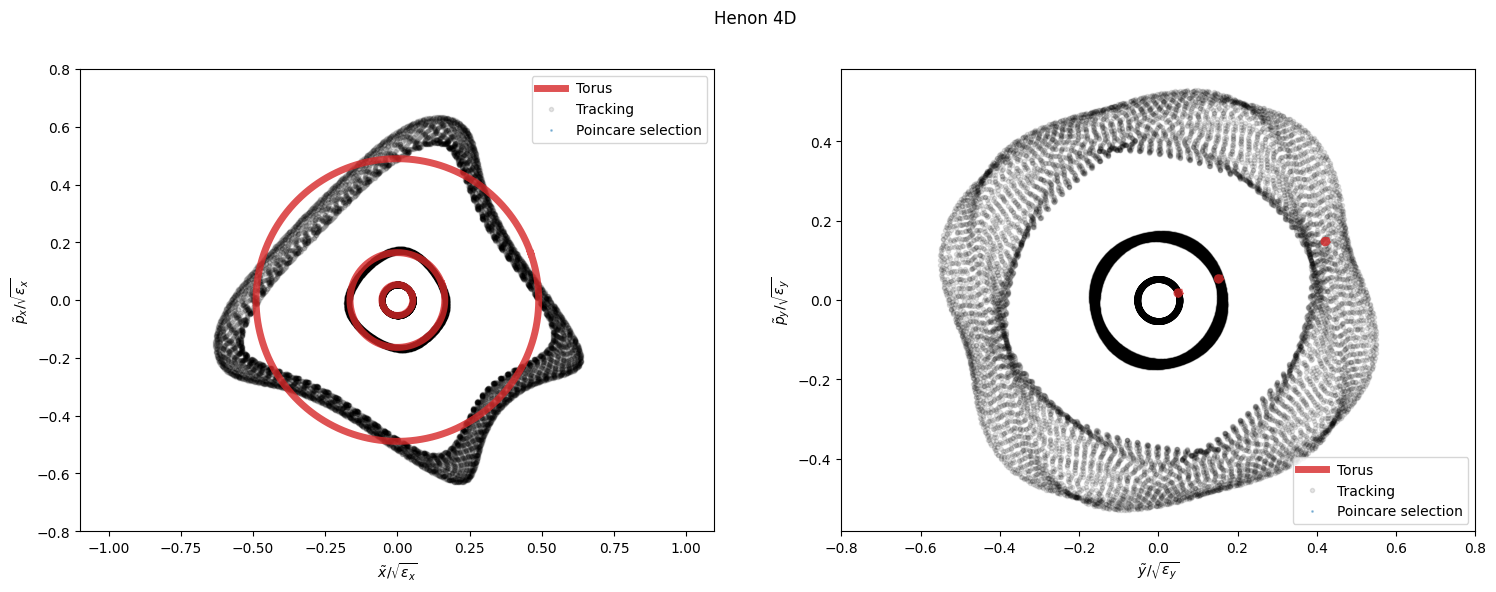

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus

# import nafflib
import nafflib.naomi as mi


# Henon parameters:
# ---
nturns = int(5e4)
points = np.array([0.05,0.15,0.4])[::-1]
# points = np.linspace(0.05,0.6,10)
slope  = 0.35

# coupling = 0.4
# Qx0 = 0.25 - 4*np.sqrt(3)/1000
# Qy0 = np.sqrt(2) - 1

coupling = 0.3
Qx0 = 0.25 - 2*np.sqrt(3)/1000
Qy0 = np.sqrt(2) - 1
# ------------



particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx0,
                                                                            Qy = Qy0,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)



fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    N_start = 0


    n_harm = 150
    w_order= 4
    Qvec   = [nafflib.tune(part[plane],part[f'p{plane}'],window_order=w_order) for plane in ['x','y']]
    Ax,Qx  = nafflib.harmonics( part['x'],part[f'px'],num_harmonics = n_harm,window_order=w_order)
    Ay,Qy  = nafflib.harmonics( part['y'],part[f'py'],num_harmonics = n_harm,window_order=w_order)
    

    max_n       = 40
    max_alias   = 10
    warning_tol = 1e-7
    nx  = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    ny  = nafflib.linear_combinations(Qy,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)


    Ix_avg  = mi.pdq_avg_integral(Ax,nx,idx=0) + mi.pdq_avg_integral(Ay,ny,idx=0)
    Iy_avg  = mi.pdq_avg_integral(Ax,nx,idx=1) + mi.pdq_avg_integral(Ay,ny,idx=1)

    Ax = [np.sqrt(2*Ix_avg)*np.exp(1j*np.angle(part['x'][0] - 1j*part['px'][0]))]
    Qx = [Qvec[0]]
    nx = [(1,0,0)]

    Ay = [np.sqrt(2*Iy_avg)*np.exp(1j*np.angle(part['y'][0] - 1j*part['py'][0])),np.sqrt(1e-5)*np.exp(1j*np.angle(part['x'][0] - 1j*part['px'][0]))]
    Qy = [Qvec[1],-Qvec[0]]
    ny = [(0,1,0),(-1,0,0)]

    mytorus = pytorus.Torus(Ax,Ay,nx,ny)
    

    theta_vec   = 2 * np.pi*Qvec[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*Qvec[1]* N_start
    

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    # plt.plot(x_r,px_r,'.',ms=2,color='C0',alpha=0.4)

    plt.sca(axes[1])
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    # plt.plot(y_r,py_r,'.',ms=2,color='C0',alpha=0.4)


    for plane,ax in zip(['x','y'],axes):
        plt.sca(ax)
        plt.plot(part[plane][:10000],part[f'p{plane}'][:10000],'.',color='k',alpha=0.1,zorder=-20)

        #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
        # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # SAVE
    #===============================
    RADIUS = 1.5
    mesh = mytorus.to_mesh('x',num_angles=500,num_slices=200,r_forced=RADIUS,scale_transverse=0.97)

    for idx,theta_chosen in enumerate([0,4*np.pi/3]):
        slice_x,slice_y = mytorus.slice('x',theta_vec,[theta_chosen])
        slice_x,slice_y = slice_x[0],slice_y[0]
        mesh['main'].meta[f'x-px {idx}'] = [[_x,_px,0] for _x,_px in zip(slice_x[:,0],slice_x[:,1])]
        mesh['sec'].meta[f'x-px {idx}']  = [[_x,_px,0] for _x,_px in zip(slice_y[:,0],slice_y[:,1])]

    # main_path,sec_path = mytorus.draw_path('x',Qx=Qvec[0],Qy=Qvec[1],N = np.arange(1000),r_forced=RADIUS)
    # mesh['main'].meta['draw_path'] = main_path
    # mesh['sec'].meta['draw_path'] = sec_path
    # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]


    # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    mesh['main'].to_json(f'data/normal/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    mesh['sec'].to_json(f'data/normal/TORUS_{str(p_idx+1).zfill(3)}_X_coupling.json')
    #===============================

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    plt.xlim(-0.8,0.8)
    plt.ylim(-0.8,0.8)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [11]:
mytorus

In [6]:
Qy

[np.float64(0.41420691889746813)]

In [7]:
ny

[(0, 1, 0)]

In [34]:
lice_y

array([[0.42413603, 0.14844761],
       [0.42414254, 0.14842882],
       [0.42414893, 0.14840998],
       ...,
       [0.42412265, 0.14848507],
       [0.4241294 , 0.14846636],
       [0.42413603, 0.14844761]])

(-0.49426033430812405,
 0.49421111018548514,
 -0.4942887332058687,
 0.4941132969021321)

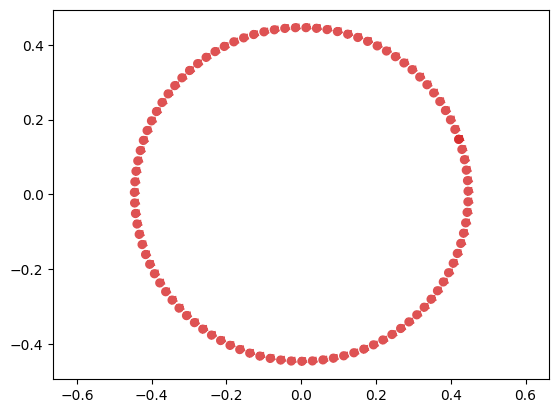

In [37]:
# slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
# slice_x,slice_y = slice_x[0],slice_y[0]
plt.figure()
for idx,theta_chosen in enumerate(np.linspace(0,2*np.pi,100)):
    slice_x,slice_y = mytorus.slice('x',theta_vec,[theta_chosen])
    slice_x,slice_y = slice_x[0],slice_y[0]
    # plt.plot(lice_y[:,0],lice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)


plt.xlim(-0.8,0.8)
plt.ylim(-0.8,0.8)
plt.axis('Equal')

---
# Export for Blender
---

In [2]:
main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=5)
main_mesh.to_json('data/TORUS_001_X.json')


---
# Matplotlib tests
---

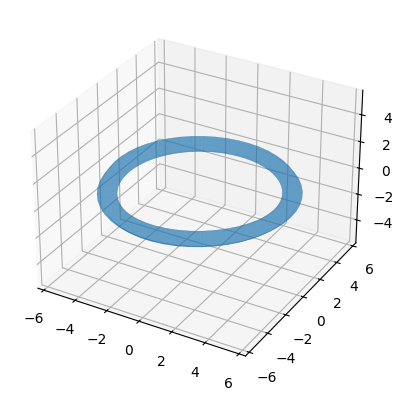

In [3]:

main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)

main_mesh.to_pickle('torus_henon.pkl')
main_mesh.to_json('torus_henon.json')



main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate the polygons for each face

poly3d = [[main_mesh.verts[vert_id] for vert_id in face] for face in main_mesh.faces]

# Create a Poly3DCollection object
collection = Poly3DCollection(poly3d, edgecolors='k', linewidths=0, alpha=0.5)
ax.add_collection3d(collection)

# Corrected auto scaling
scale = np.concatenate(main_mesh.verts).flatten()  # Corrected here
ax.auto_scale_xyz(scale, scale, scale)

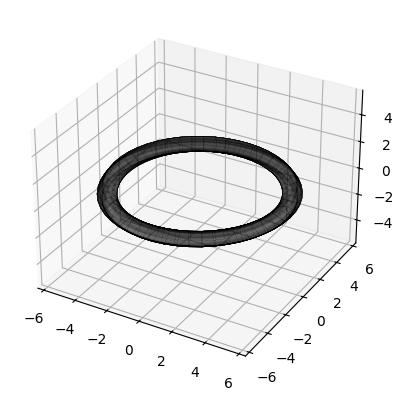

In [4]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

verts = main_mesh.verts
faces = main_mesh.faces

# Create lines for the wireframe
edges = set()
for face in faces:
    face_edges = [(face[i], face[(i+1) % len(face)]) for i in range(len(face))]
    for edge in face_edges:
        edges.add(tuple(sorted(edge)))  # Add each edge as a sorted tuple to avoid duplicates

# Convert edge vertices to line segments for plotting
lines = [[verts[edge[0]], verts[edge[1]]] for edge in edges]

# Create a Line3DCollection from the lines
line_collection = Line3DCollection(lines, colors='k', linewidths=0.1)

# Add the collection to the plot
ax.add_collection(line_collection)

# # Setting the limits to frame the wireframe (might need adjusting)
# ax.set_xlim([verts[:,0].min(), verts[:,0].max()])
# ax.set_ylim([verts[:,1].min(), verts[:,1].max()])
# ax.set_zlim([verts[:,2].min(), verts[:,2].max()])
ax.auto_scale_xyz(scale, scale, scale)

plt.show()

In [21]:
%matplotlib widget

633834
0.7301421260068325 0.017324817203122633 0.7474669432099551
633834
0.7181265270616723 0.005299403339806287 0.7234259304014786


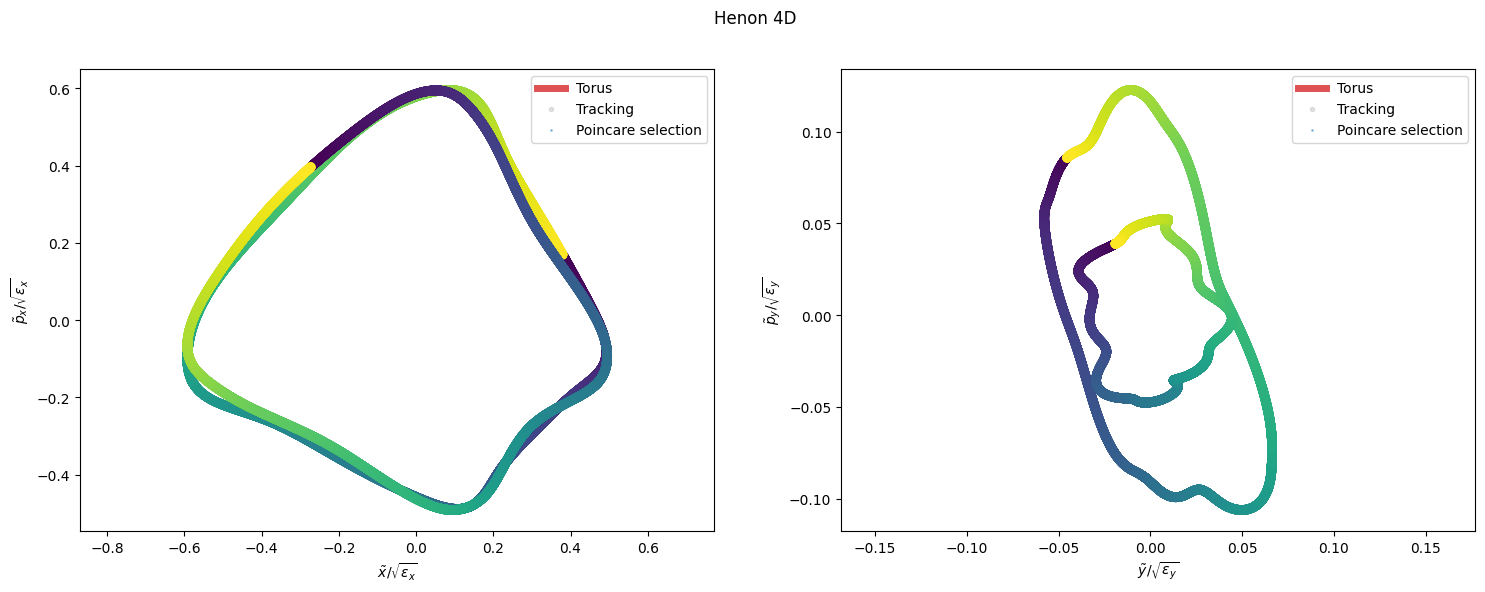

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)
# points = np.array([0.1,0.2,0.3,0.4,0.41,0.45,0.51,0.555])
# points = np.array([0.4])
points = np.array([0.05,0.15,0.4])[::-1][:1]

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)

# x_area
n_harm = 200
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    for N_start in [0,3]:
    # N_start = 3

        supersampling = np.arange(1,int(1e7))
        superperiod = int(supersampling[np.argmin(np.abs(np.round(supersampling*fundamental_tunes[1])-supersampling*fundamental_tunes[1]))])
        print(superperiod)
        N_r = np.arange(int(1e4))*superperiod

        Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
        Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # x_r,px_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes, N_r)
        x_r,px_r = nafflib.generate_signal(Ax,Qx, N_start + N_r)

        Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
        Cy,err,_f = nafflib.find_linear_combinations(Qy,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # combi,err,_f = nafflib.find_linear_combinations(frequencies,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # y_r,py_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes,N_r)
        y_r,py_r = nafflib.generate_signal(Ay,Qy, N_start + N_r)


        mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
        

        theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,10000)
        theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
        

        slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
        slice_x,slice_y = slice_x[0],slice_y[0]



        plt.sca(axes[0])
        plt.plot(slice_x[:,0]-np.mean(slice_x[:,0]),slice_x[:,1]-np.mean(slice_x[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
        plt.scatter(slice_x[:,0]-np.mean(slice_x[:,0]),slice_x[:,1]-np.mean(slice_x[:,1]),c=theta_vec)
        # plt.plot(x_r-np.mean(slice_x[:,0]),px_r-np.mean(slice_x[:,1]),'.',ms=2,color='C0',alpha=0.4)

        plt.sca(axes[1])
        plt.plot(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
        plt.scatter(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),c=theta_vec)
        # plt.plot(y_r-np.mean(slice_y[:,0]),py_r-np.mean(slice_y[:,1]),'.',ms=2,color='C0',alpha=0.4)


    # for plane,ax in zip(['x','y'],axes):
    #     plt.sca(ax)
    #     plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

    #     #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
    #     # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # # SAVE
    # #===============================
    # mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=3,scale_transverse=0.97)
    # mesh['main'].meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['sec'].meta['x-px']  = [[_x,_px,0] for _x,_px in zip(part['y'][:1000],part['py'][:1000])]

    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]


    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['main'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    # mesh['sec'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X_coupling.json')
    # #===============================
        from shapely import Polygon
        x_polygon = Polygon([(_x,_px) for _x,_px in zip(slice_x[:,0],slice_x[:,1])])
        y_polygon = Polygon([(_x,_px) for _x,_px in zip(slice_y[:,0],slice_y[:,1])])
        print(x_polygon.area,y_polygon.area,x_polygon.area + y_polygon.area)

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    # plt.xlim(-0.5,0.5)
    # plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [65]:
len(Ax)

126

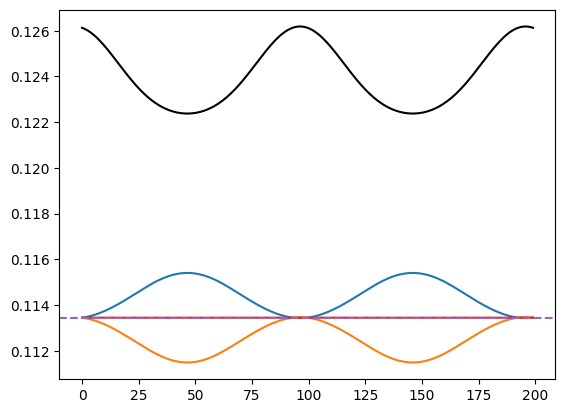

In [19]:
mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
from shapely import Polygon  

theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,5000)
theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start + np.linspace(0,2*np.pi,200)

plt.figure()
slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)

Ixx = []
Ixy = []
Ix  = []
Jx  = []
for _sx,_sy,id in zip(slice_x,slice_y,np.arange(len(slice_x))):
    
    x_polygon = Polygon([(_x,_px) for _x,_px in zip(_sx[:,0],_sx[:,1])])
    y_polygon = Polygon([(_x,_px) for _x,_px in zip(_sy[:,0],_sy[:,1])])


    # print(x_polygon.area,y_polygon.area,x_polygon.area + y_polygon.area)
    
    Ixx.append(x_polygon.area)
    Ixy.append(-y_polygon.area)
    Ix.append(x_polygon.area - y_polygon.area)

    Jx.append(np.mean(_sx[:,0]**2 + _sx[:,1]**2))

Ixx = np.array(Ixx)/np.pi/2
Ixy = np.array(Ixy)/np.pi/2
Ix  = np.array(Ix)/np.pi/2
Jx  = np.array(Jx)/2
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixx-Ixx[0]),'-',color='C0')
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixy-Ixy[0]),'-',color='C1')
plt.plot(np.arange(len(Ix)),Ix,'-',color='C3')
plt.plot(np.arange(len(Ix)),Jx,'-',color='k')

plt.axhline(mytorus.Ix,ls='--',color='C4')


In [11]:
mytorus.Ix

0.11344918930167401

In [15]:
mytorus.Ix

0.11344972707912353

In [16]:
0.11344972707912353 - 0.11344918930167401

5.377774495163301e-07

In [9]:
Ix-mytorus.Ix

array([ 2.11566008e-07,  2.99449189e-07,  3.92682473e-07,  4.80351815e-07,
        5.50953558e-07,  5.93269909e-07,  5.97298577e-07,  5.55175718e-07,
        4.62020829e-07,  3.16626924e-07,  1.21921403e-07, -1.14866300e-07,
       -3.82374808e-07, -6.65636283e-07, -9.46942872e-07, -1.20700591e-06,
       -1.42632797e-06, -1.58668206e-06, -1.67257620e-06, -1.67257653e-06,
       -1.58037068e-06, -1.39547302e-06, -1.12350383e-06, -7.76012012e-07,
       -3.69850789e-07,  7.38446547e-08,  5.30995568e-07,  9.76126731e-07,
        1.38400093e-06,  1.73121698e-06,  1.99765611e-06,  2.16767993e-06,
        2.23100829e-06,  2.18323467e-06,  2.02596673e-06,  1.76660734e-06,
        1.41781494e-06,  9.96699607e-07,  5.23821460e-07,  2.20627294e-08,
       -4.84557393e-07, -9.72061920e-07, -1.41763541e-06, -1.80064033e-06,
       -2.10349805e-06, -2.31241174e-06, -2.41791666e-06, -2.41524905e-06,
       -2.30452922e-06, -2.09075697e-06, -1.78361930e-06, -1.39711251e-06,
       -9.48983266e-07, -

In [2]:
mytorus.Ix,mytorus.Iy

(0.11344972707912353, 0.09761183168637373)

In [3]:
mytorus.Jx,mytorus.Jy


(0.12408502953631323, 0.10244669368722036)

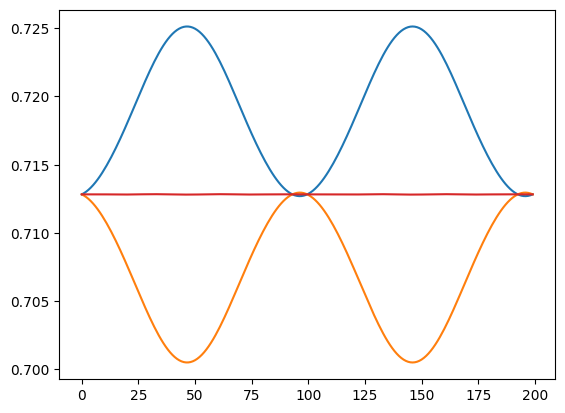

In [79]:
plt.figure()

plt.plot(np.arange(len(Ix)),Ix[0] + (Ixx-Ixx[0]),'-',color='C0')
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixy-Ixy[0]),'-',color='C1')
plt.plot(np.arange(len(Ix)),Ix,'-',color='C3')

plt.axhline()


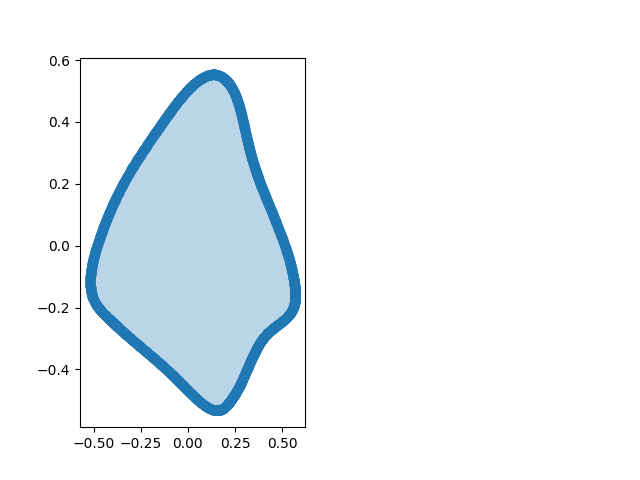

In [49]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon, plot_points

# from figures import GRAY, RED, SIZE, set_limits

fig = plt.figure()#, figsize=SIZE, dpi=90)

# 3: invalid polygon, ring touch along a line
ax = fig.add_subplot(121)

# ext = [(0, 0), (0, 2), (2, 2), (2, 0), (0, 0)]
# int = [(0.5, 0), (1.5, 0), (1.5, 1), (0.5, 1), (0.5, 0)]
# polygon = Polygon(ext, [int])

plot_polygon(polygon, ax=ax)#, add_points=False, color=RED)
# plot_points(polygon, ax=ax, color=GRAY, alpha=0.7)
plt.show()



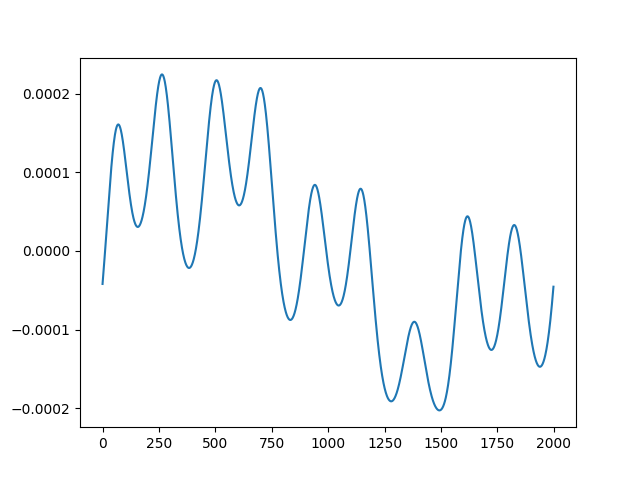

In [25]:
plt.figure()
plt.plot(np.diff(slice_y[:,0]))

(-0.06222909667468761,
 0.15538151229220126,
 -0.09584670131693715,
 0.12176390764995171)

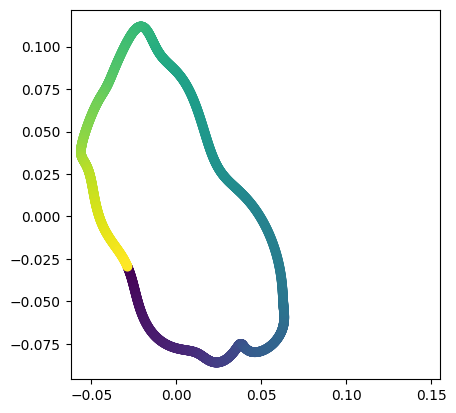

In [14]:

plt.figure()
# plt.plot(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
plt.scatter(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),c=theta_vec)

plt.axis('square')